# <center> **MNIST Digit Classification using CNN** </center>

## **Objective**:
> #### Build a clean and beginner-friendly CNN model for handwritten digit classification.

> #### Achieve 90%+accuracy on MNIST dataset.

---

### Import libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, Input
)

from tensorflow.keras.datasets import mnist
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [10]:
import streamlit
print(streamlit.__version__)

1.51.0


### Load and Split

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

### Count of Each Digit

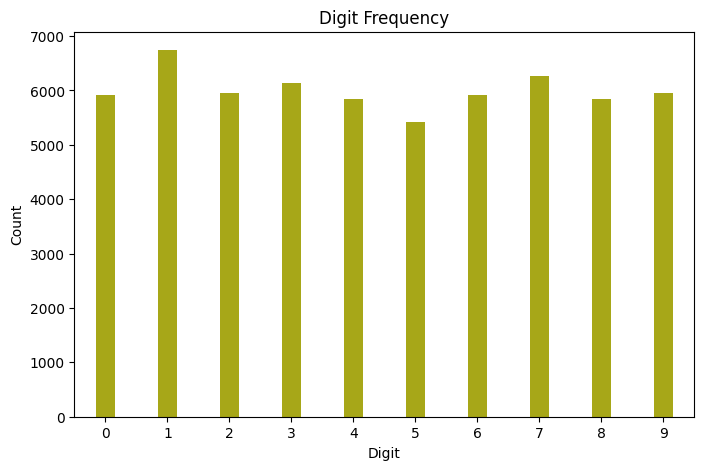

In [13]:
df = pd.Series(y_train)

plt.figure(figsize= (8, 5))
sns.countplot(x= df, color= 'y', width= 0.3)
plt.title("Digit Frequency")
plt.xlabel("Digit")
plt.ylabel("Count")
plt.show()

### Percentage of each digit

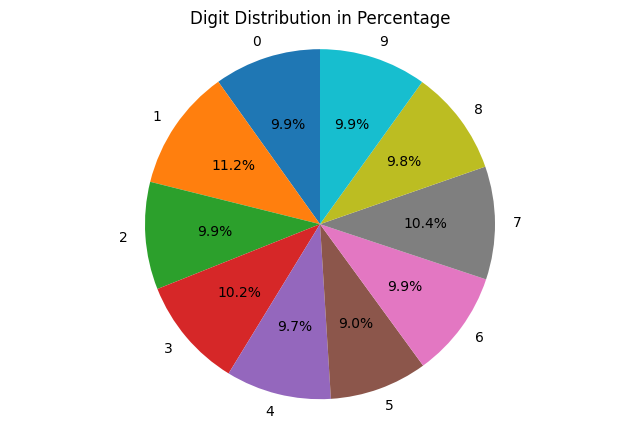

In [24]:
# Count frequency of each digit
digit_count = df.value_counts().sort_index()

plt.figure(figsize= (8, 5))
plt.pie(digit_count, labels= digit_count.index, autopct= "%1.1f%%", startangle= 90)
plt.title("Digit Distribution in Percentage")
plt.axis('equal')
plt.show()

### Preprocess MNIST dataset

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-2, 28, 28, 1)

### First 10 images

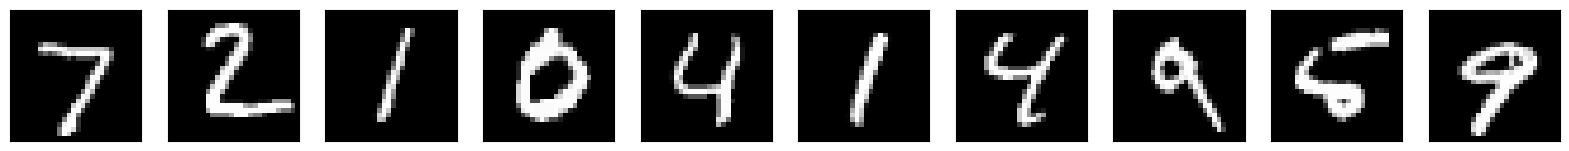

In [ ]:
n = 10

plt.figure(figsize= (20, 4))
for i in range(n):
    
    
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()

    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()

plt.close()

### CNN Model Architecture

In [4]:
model = Sequential([
    Input(shape= (28, 28, 1)),

    Conv2D(32, (3, 3), activation= "relu"),

    MaxPooling2D((2,2)),

    Conv2D(64, (3, 3), activation= "relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation= "relu"),
    Dropout(0.3),
    Dense(10, activation= "softmax")
])

### Compile

In [5]:
model.compile(
    optimizer= "adam",
    loss= "sparse_categorical_crossentropy",
    metrics= ["accuracy"]
)

### Train CNN model

In [6]:
model.fit(
    X_train,
    y_train,
    epochs= 10,
    batch_size= 128,
    validation_split= 0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 62s 141ms/step - accuracy: 0.9150 - loss: 0.2775 - val_accuracy: 0.9828 - val_loss: 0.0602
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 54s 127ms/step - accuracy: 0.9749 - loss: 0.0813 - val_accuracy: 0.9868 - val_loss: 0.0476
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 59s 140ms/step - accuracy: 0.9817 - loss: 0.0594 - val_accuracy: 0.9870 - val_loss: 0.0463
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 136ms/step - accuracy: 0.9859 - loss: 0.0478 - val_accuracy: 0.9897 - val_loss: 0.0372
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 124ms/step - accuracy: 0.9875 - loss: 0.0400 - val_accuracy: 0.9910 - val_loss: 0.0332
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 49s 117ms/step - accuracy: 0.9883 - loss: 0.0360 - val_accuracy: 0.9883 - val_loss: 0.0406
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 119ms/step - accuracy: 0.9912 - loss: 0.0282 - val_accuracy: 0.9893 - val_loss: 0.0382
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 50s 118ms/step - accuracy: 0.9916 - loss: 0

### Test Accuracy

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy: ", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9926 - loss: 0.0263
Test Accuracy:  0.9926000237464905


### Predictions

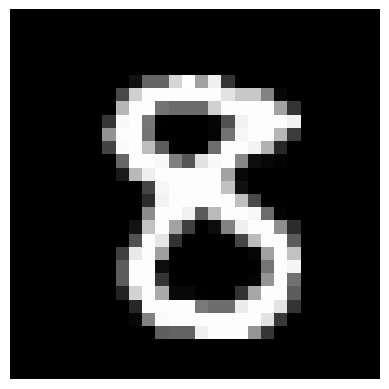

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Actual:  8
Predicted:  8


In [16]:
plt.imshow(X_test[899].reshape(28, 28), cmap= "gray")
plt.axis("off")
plt.show()

pred = model.predict(X_test[899].reshape(1, 28, 28, 1))
print("Actual: ", y_test[899])
print("Predicted: ", pred.argmax())